# 📊 Evaluasi Klasifikasi (Lightweight Fine-Tuning)


In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG19, InceptionV3, MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow version: 2.10.0


## 1. Reproduksi Data Validasi


In [2]:
if os.name == 'posix':
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
else:
    BASE_DIR = r'D:\Antigravity\Visual Based Rekomender Sistem'

FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')

IMG_DIR = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')

MODEL_DIR = os.path.join(BASE_DIR, 'models', 'lightweight')
EVAL_DIR  = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'lightweight', 'hasil_evaluasi')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print("Memuat dataset untuk evaluasi klasifikasi...")
df_full = pd.read_csv(FULL_CSV)
df_full['full_path'] = df_full['image_name'].apply(
    lambda x: os.path.join(IMG_DIR, os.path.normpath(str(x).replace('img/', '', 1))) if str(x).startswith('img/') else os.path.join(IMG_DIR, os.path.normpath(str(x)))
)

df_train_all = df_full[df_full['split'] == 'train'].copy()
cat_counts = df_train_all['category'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index.tolist()
df_train_all = df_train_all[df_train_all['category'].isin(valid_cats)].reset_index(drop=True)

label_enc = LabelEncoder()
df_train_all['category_idx'] = label_enc.fit_transform(df_train_all['category'])
num_classes = len(label_enc.classes_)
class_names = label_enc.classes_

_, val_df = train_test_split(
    df_train_all, test_size=0.2, 
    stratify=df_train_all['category_idx'], random_state=42
)
val_df['category_str'] = val_df['category_idx'].astype(str)

print(f"Total gambar validasi untuk pengujian : {len(val_df)}")

Memuat dataset untuk evaluasi klasifikasi...
Total gambar validasi untuk pengujian : 5174


## 2. Setup Config Model


In [3]:
BATCH_SIZE = 32
MODEL_CONFIGS = {
    'resnet50': {'class': ResNet50, 'input_size': (224, 224), 'preprocess': tf.keras.applications.resnet50.preprocess_input},
    'vgg19': {'class': VGG19, 'input_size': (224, 224), 'preprocess': tf.keras.applications.vgg19.preprocess_input},
    'inceptionv3': {'class': InceptionV3, 'input_size': (299, 299), 'preprocess': tf.keras.applications.inception_v3.preprocess_input},
    'mobilenetv3': {'class': MobileNetV3Large, 'input_size': (224, 224), 'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input},
}

def build_finetune_model(cfg, num_classes):
    base_model = cfg['class'](weights=None, include_top=False, input_shape=cfg['input_size']+(3,))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', name='feature_embedding')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', name='classification_head')(x)
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

## 3. Proses Evaluasi Semua Model (Loop Utuh)



EVALUASI KLASIFIKASI: RESNET50
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 31s 162ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.62      0.65      0.63       806
          Cardigans       0.49      0.42      0.45       137
              Denim       0.73      0.55      0.63        60
            Dresses       0.87      0.83      0.85       428
       Graphic_Tees       0.90      0.74      0.81       177
      Jackets_Coats       0.60      0.56      0.58       378
      Jackets_Vests       0.68      0.41      0.52       162
           Leggings       0.70      0.80      0.75      1446
              Pants       0.68      0.40      0.50        86
  Rompers_Jumpsuits       0.80      0.85      0.83       690
       Shirts_Polos       0.57      0.44      0.50       131
             Shorts       0.62      0.65      0.

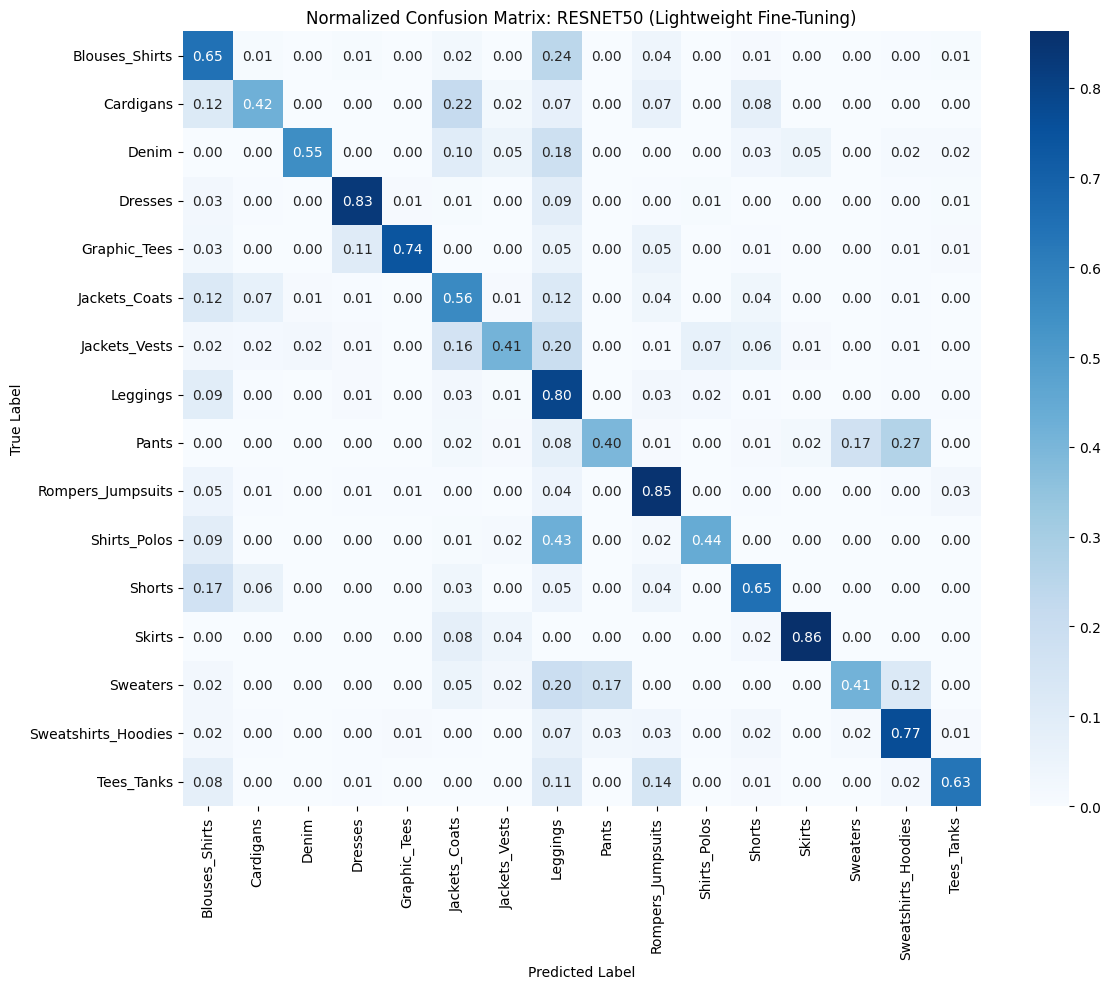

Metrics (Macro): Acc=0.7093, Prec=0.6934, Rec=0.6235, F1=0.6515
✅ Report disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\resnet50_classification_report.txt
✅ Confusion Matrix disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\resnet50_confusion_matrix.png

EVALUASI KLASIFIKASI: VGG19
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 23s 102ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.55      0.60      0.58       806
          Cardigans       0.41      0.25      0.31       137
              Denim       0.49      0.57      0.52        60
            Dresses       0.78      0.77      0.77       428
       Graphic_Tees       0.75      0.68      0.71       177
      Jackets_Coats       0.51      

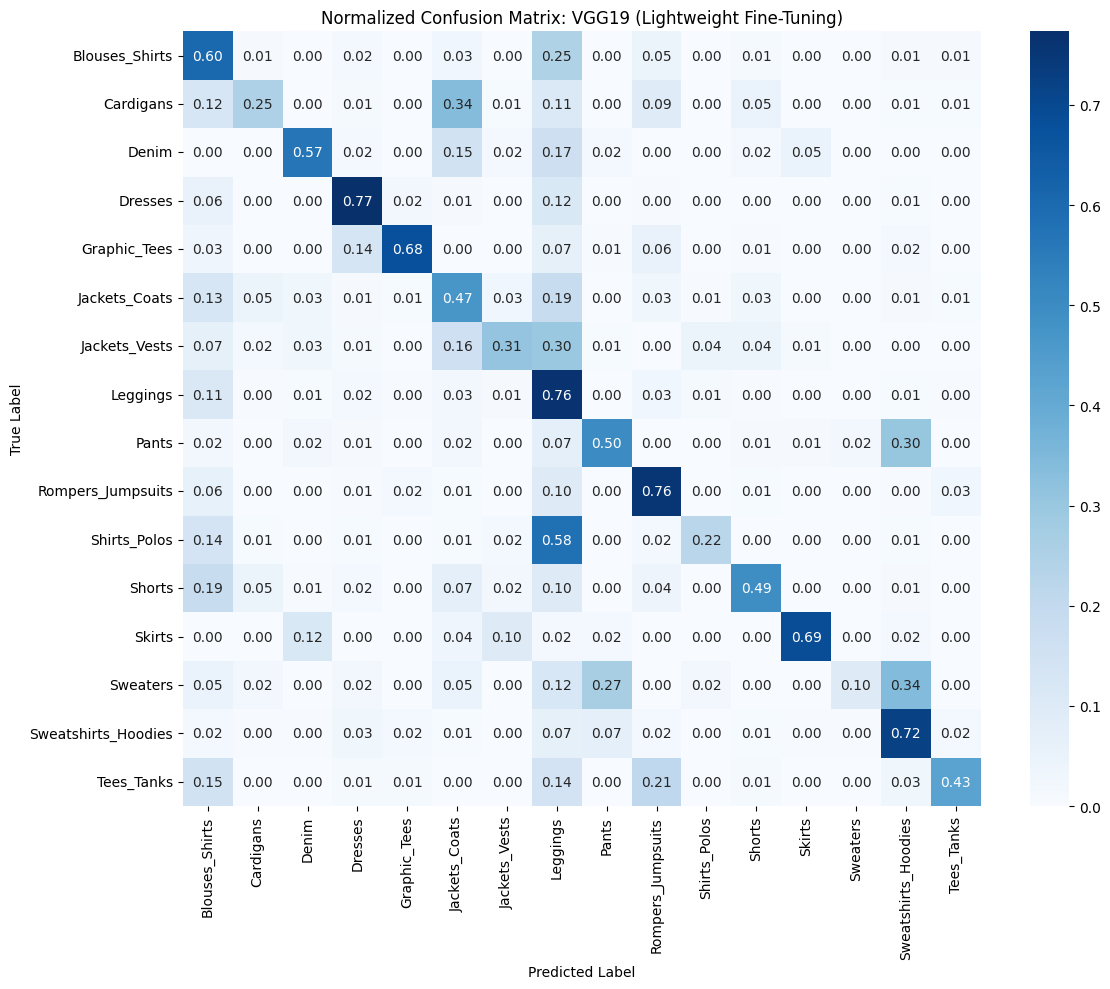

Metrics (Macro): Acc=0.6384, Prec=0.6104, Rec=0.5199, F1=0.5455
✅ Report disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\vgg19_classification_report.txt
✅ Confusion Matrix disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\vgg19_confusion_matrix.png

EVALUASI KLASIFIKASI: INCEPTIONV3
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 13s 72ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.64      0.63      0.64       806
          Cardigans       0.47      0.29      0.36       137
              Denim       0.76      0.57      0.65        60
            Dresses       0.73      0.86      0.79       428
       Graphic_Tees       0.82      0.61      0.70       177
      Jackets_Coats       0.53      0

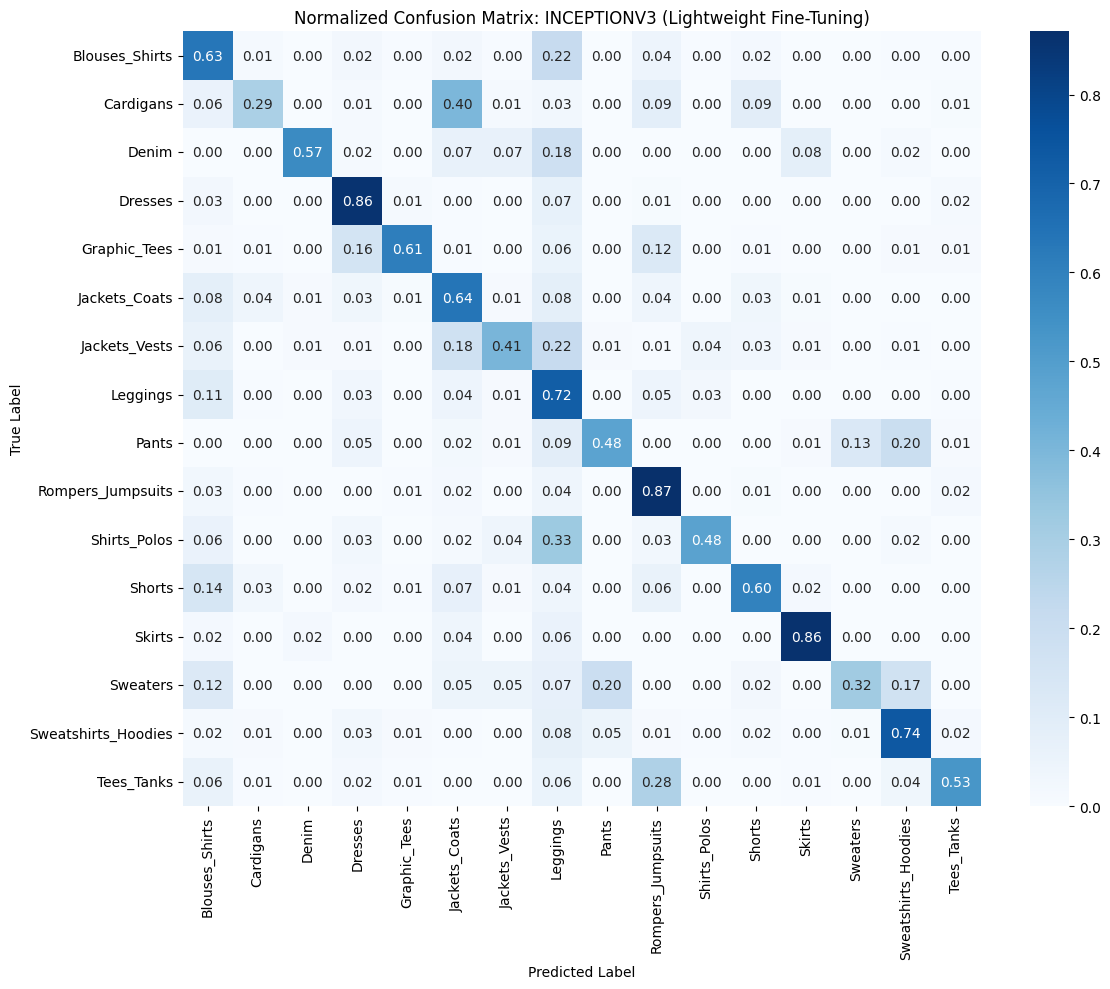

Metrics (Macro): Acc=0.6830, Prec=0.6581, Rec=0.5994, F1=0.6201
✅ Report disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\inceptionv3_classification_report.txt
✅ Confusion Matrix disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\inceptionv3_confusion_matrix.png

EVALUASI KLASIFIKASI: MOBILENETV3
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 5s 28ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.60      0.67      0.64       806
          Cardigans       0.54      0.24      0.33       137
              Denim       0.66      0.55      0.60        60
            Dresses       0.81      0.82      0.82       428
       Graphic_Tees       0.75      0.78      0.76       177
      Jackets_Coats       

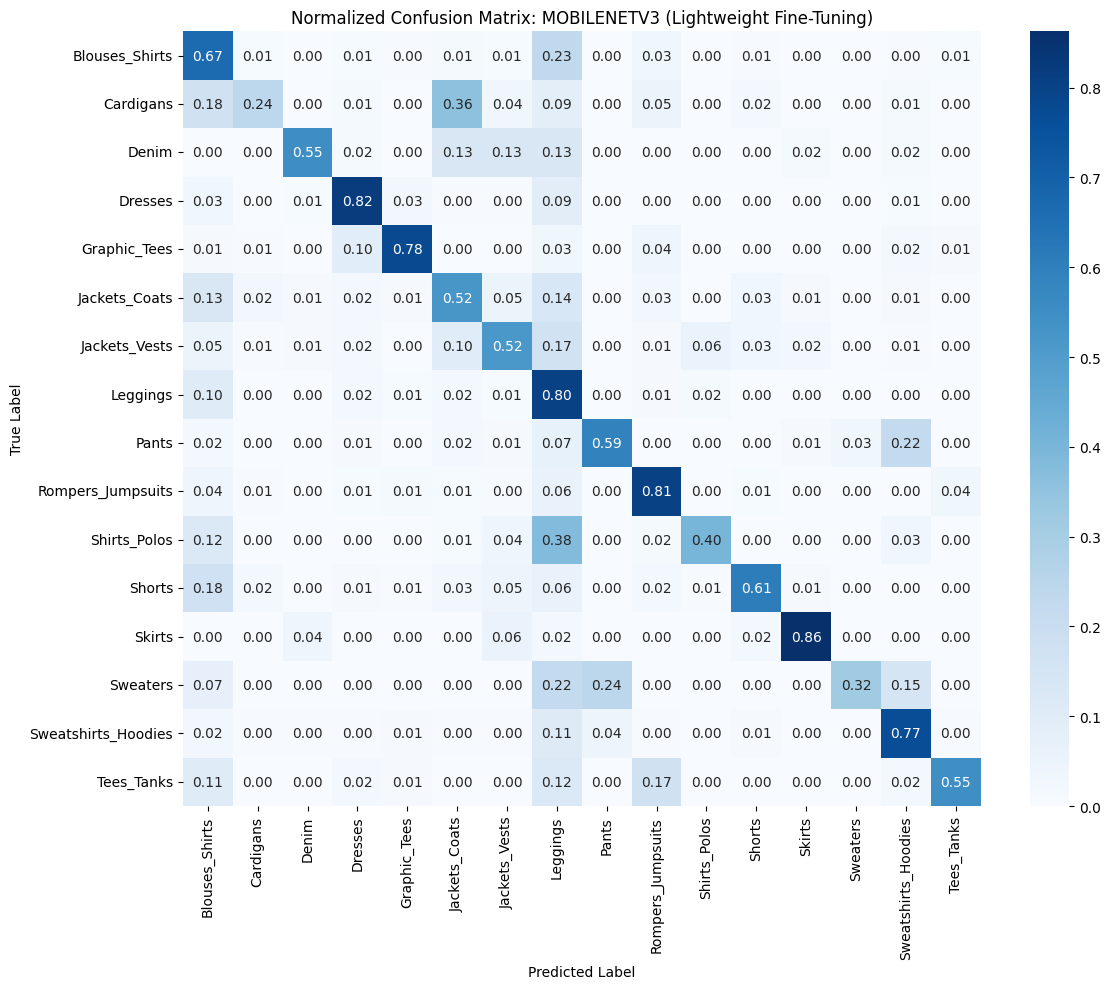

Metrics (Macro): Acc=0.7031, Prec=0.6974, Rec=0.6133, F1=0.6414
✅ Report disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\mobilenetv3_classification_report.txt
✅ Confusion Matrix disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\mobilenetv3_confusion_matrix.png

Evaluasi klasifikasi selesai!

✅ Hasil evaluasi klasifikasi disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\lightweight_classification_results.csv
         Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  \
0     resnet50  0.709316         0.693399      0.623528        0.651532   
1        vgg19  0.638384         0.610391      0.519890        0.545548   
2  inceptionv3  0.683031         0.658083      0.599434        0.620113   
3  mobilenetv3  0.703131         0.697391      0.613334        0.641372   

   Eval Time (s)  
0     

In [4]:
# ─────────────────────────────────────────────
# CELL 3: Proses Evaluasi Klasifikasi Semua Model Lightweight
# ─────────────────────────────────────────────
eval_results = []

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*50}\nEVALUASI KLASIFIKASI: {model_name.upper()}\n{'='*50}")
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}_finetuned.h5")
    if not os.path.exists(model_path):
        print(f"⚠️ Model {model_path} tidak ditemukan! Harap jalankan training terlebih dahulu.")
        continue
        
    val_datagen = ImageDataGenerator(preprocessing_function=cfg['preprocess'])
    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df, x_col='full_path', y_col='category_str', 
        target_size=cfg['input_size'], batch_size=BATCH_SIZE, 
        class_mode='sparse', shuffle=False
    )
    
    model = build_finetune_model(cfg, num_classes)
    model.load_weights(model_path)
    
    print(f"Memprediksi {len(val_df)} gambar validasi...")
    start_time = time.time()
    preds = model.predict(val_gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes
    eval_time = time.time() - start_time
    
    # Classification Report
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_text = classification_report(y_true, y_pred, target_names=class_names)
    print("\n--- Classification Report ---")
    print(report_text)
    
    report_path = os.path.join(EVAL_DIR, f"{model_name}_classification_report.txt")
    with open(report_path, "w") as f:
        f.write(f"=== CLASSIFICATION REPORT: {model_name.upper()} (Lightweight Fine-Tuning) ===\n\n")
        f.write(report_text)
    print(f"Report disimpan di: {report_path}")
        
    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
                
    plt.title(f'Normalized Confusion Matrix: {model_name.upper()} (Lightweight Fine-Tuning)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    cm_path = os.path.join(EVAL_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=300)
    plt.show()
    plt.close()
    
    # Simpan metrics makro ke eval_results
    acc = report['accuracy']
    macro_p = report['macro avg']['precision']
    macro_r = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    
    eval_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1-Score': macro_f1,
        'Eval Time (s)': round(eval_time, 2)
    })
    
    print(f"Metrics (Macro): Acc={acc:.4f}, Prec={macro_p:.4f}, Rec={macro_r:.4f}, F1={macro_f1:.4f}")
    print(f"✅ Report disimpan di: {report_path}")
    print(f"✅ Confusion Matrix disimpan di: {cm_path}")
    
    del model, val_gen
    tf.keras.backend.clear_session()

print("\nEvaluasi klasifikasi selesai!")

# ── Tampilkan DataFrame Hasil Evaluasi ──
df_eval = pd.DataFrame(eval_results)
eval_csv_path = os.path.join(EVAL_DIR, 'lightweight_classification_results.csv')
df_eval.to_csv(eval_csv_path, index=False)
print(f"\n✅ Hasil evaluasi klasifikasi disimpan di: {eval_csv_path}")
print(df_eval)